In [1]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.6 MB/s eta 0:00:00


In [6]:
import cv2
import random
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

model = YOLO("yolov8n.pt")

def getColours(idx):
    random.seed(idx)
    return tuple(random.randint(0, 255) for _ in range(3))


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


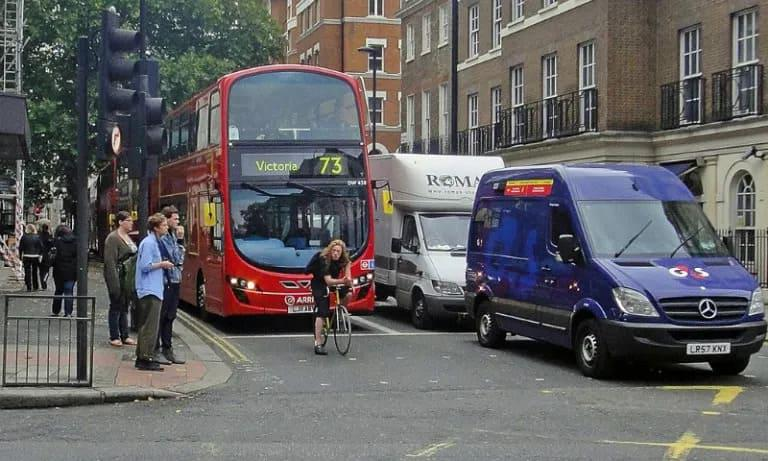

In [7]:
img = cv2.imread("YOLO_OBJECT_DETECTION-ON_IMAGE.jpg")

if img is None:
    raise ValueError("❌ Image not found")

cv2_imshow(img)


In [8]:
results = model.predict(
    img,
    conf=0.3
)

result = results[0]



0: 384x640 5 persons, 1 bicycle, 1 car, 2 buss, 1 truck, 2 traffic lights, 476.3ms
Speed: 16.9ms preprocess, 476.3ms inference, 47.1ms postprocess per image at shape (1, 3, 384, 640)


In [9]:
if result.boxes is not None:
    boxes = result.boxes.xyxy.cpu()
    classes = result.boxes.cls.cpu()

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box)

        cls = int(classes[i])
        class_name = model.names[cls]

        colour = getColours(cls)

        cv2.rectangle(img, (x1, y1), (x2, y2), colour, 2)
        cv2.putText(
            img,
            class_name,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            colour,
            2
        )

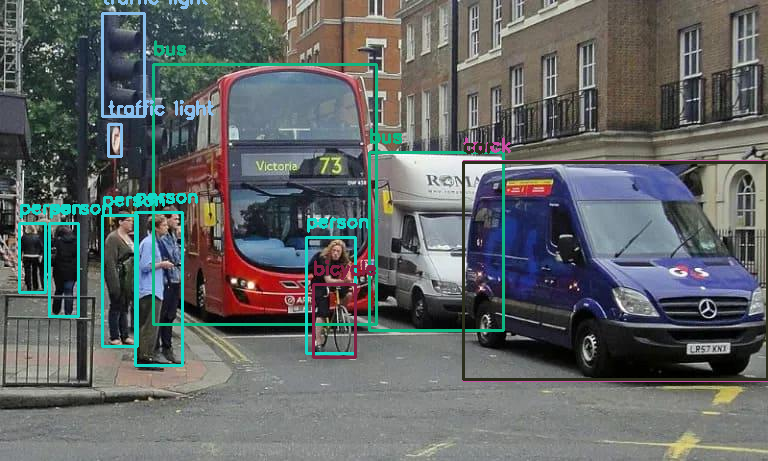

In [ ]:
cv2_imshow(img)